# Experimenting with CST.csv files to extract env

After downloading all the ctd data we converted them into csv to be able to read the data 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

## Loading Data

We will experiment with the first batch 1

In [3]:
data_path = "../real-data-ctds/csv_output/ctd_batch_1.csv"
data = pd.read_csv(data_path)
data.head()

,date,t1,c1,p1,sal,sv
0,20211003T000000.714Z,9.4602,3.39950,97.318,31.2671,1484.917
1,20211003T000001.733Z,9.4604,3.39950,97.318,31.2670,1484.917
2,20211003T000002.714Z,9.4604,3.39949,97.318,31.2670,1484.917
3,20211003T000003.756Z,9.4604,3.39949,97.318,31.2669,1484.917
4,20211003T000004.713Z,9.4603,3.39949,97.318,31.2670,1484.917


## Data visulaization

In [4]:
data.columns

Index(['date', 't1', 'c1', 'p1', 'sal', 'sv'], dtype='object')

As we see here we have: 

| Column | Meaning      | Unit | Use in Bellhop                          |
| ------ | ------------ | ---- | --------------------------------------- |
| `date` | timestamp    | ISO  | (optional) for labeling                 |
| `t1`   | temperature  | °C   | used to compute sound speed or as check |
| `c1`   | conductivity | S/m  | used to compute salinity if missing     |
| `p1`   | pressure     | dbar | approximates depth (1 dbar ≈ 1 m)       |
| `sal`  | salinity     | PSU  | used to compute or verify sound speed   |
| `sv`   | sound speed  | m/s  | directly used for Bellhop SSP section   |


In [6]:
data.describe()

,t1,c1,p1,sal,sv
count,8.222244e+06,8.222244e+06,8.222244e+06,8.222244e+06,8.222244e+06
mean,9.646189e+00,3.296215e+00,1.037811e+02,3.006365e+01,1.484201e+03
std,9.476776e-01,1.129980e-01,4.905967e+01,1.064791e+00,3.210682e+00
min,7.652700e+00,2.680510e+00,-3.781050e+02,2.314230e+01,1.476021e+03
25%,9.103400e+00,3.225060e+00,4.193900e+01,2.971560e+01,1.481917e+03
50%,9.573400e+00,3.324100e+00,1.123750e+02,3.024180e+01,1.485143e+03
75%,1.019320e+01,3.386420e+00,1.475522e+02,3.057930e+01,1.486287e+03
max,2.059650e+01,3.464390e+00,1.494040e+02,3.131730e+01,1.503678e+03


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8222244 entries, 0 to 8222243
Data columns (total 6 columns):
 #   Column  Dtype  
---  ------  -----  
 0   date    object 
 1   t1      float64
 2   c1      float64
 3   p1      float64
 4   sal     float64
 5   sv      float64
dtypes: float64(5), object(1)
memory usage: 376.4+ MB


# Extracting values for Env file

### Extracting Sound Speed profile

In [4]:
def extract_profile(data):
    df = data
    # Sort by pressure (acts as depth)
    df = df.sort_values('p1')

    # Filter to 0–500 m range
    df = df[(df['p1'] >= 0) & (df['p1'] <= 500)]

    # Bin by 5 m and average sound speed
    df['depth_bin'] = (df['p1'] / 5).round() * 5
    profile = df.groupby('depth_bin')['sv'].mean().reset_index()
    profile.rename(columns={'depth_bin': 'depth', 'sv': 'sound_speed'}, inplace=True)
    return profile

# profile = extract_profile(data)

In [9]:
profile.head()

,depth,sound_speed
0,0.0,1488.362225
1,40.0,1482.827696
2,95.0,1485.145294
3,100.0,1485.160480
4,110.0,1485.967827


We extracted the sound speed for each depth underwater, let's now try to visualize it

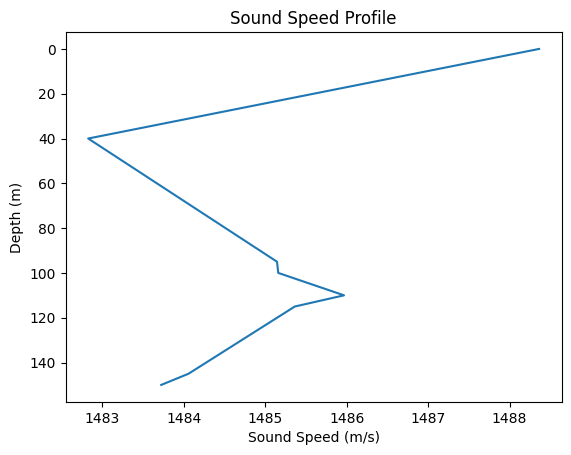

In [12]:
plt.plot(profile['sound_speed'], profile['depth'])
plt.gca().invert_yaxis()
plt.xlabel("Sound Speed (m/s)")
plt.ylabel("Depth (m)")
plt.title("Sound Speed Profile")
plt.show()

## Building and Testing an Enviroment in ARLPY

## Step 1: Create the enviroment directly from `Profile`

In [15]:
import arlpy.uwapm as pm

max_depth = profile['depth'].max()
env = pm.create_env2d(
    depth=max_depth,  # water depth (m)
    soundspeed=profile.values.tolist(),  # [[depth, c], [depth, c], ...]
    bottom_soundspeed=1600,  # for sand bottom
    rx_depth=[10, 50, 100, 150],
    rx_range=[i for i in range(0, 2001, 10)]  # receiver at 0–2000 m
)


### Validate the enviroment

In [16]:
pm.check_env2d(env)
pm.print_env(env)
pm.plot_env(env)
pm.plot_ssp(env)

                name : arlpy
   bottom_absorption : 0.1
      bottom_density : 1600
    bottom_roughness : 0
   bottom_soundspeed : 1600
               depth : 150.0
        depth_interp : linear
           frequency : 25000
           max_angle : 80
           min_angle : -80
              nbeams : 0
            rx_depth : [ 10.  50. 100. 150.]
            rx_range : [   0.   10.   20.   30.   40.   50.   60.   70.   80.   90.  100.  110.
                         120.  130.  140.  150.  160.  170.  180.  190.  200.  210.  220.  230.
                         240.  250.  260.  270.  280.  290.  300.  310.  320.  330.  340.  350.
                         360.  370.  380.  390.  400.  410.  420.  430.  440.  450.  460.  470.
                         480.  490.  500.  510.  520.  530.  540.  550.  560.  570.  580.  590.
                         600.  610.  620.  630.  640.  650.  660.  670.  680.  690.  700.  710.
                         720.  730.  740.  750.  760.  770.  780.  790.  800

The enviroment looks good!

Our Next Step is Loading all the CSV files (4GB) of data

This may break the system if loaded at once so we will load it in batches same way we read the ctd files


# The full CTD Data to enviroment

In [5]:
import glob
import pandas as pd

csv_files = glob.glob("../real-data-ctds/csv_output/ctd_batch_*.csv")
profile = pd.DataFrame()
for file in csv_files:
    batch_data = pd.read_csv(file)
    profile_batch = extract_profile(batch_data)
    profile = pd.concat([profile, profile_batch], ignore_index=True)
    
profile = profile.groupby('depth')['sound_speed'].mean().reset_index()
profile.head()


,depth,sound_speed
0,0.0,1486.549495
1,40.0,1481.760616
2,90.0,1481.232868
3,95.0,1485.081264
4,100.0,1485.148555


### Next steps

As shown above, this data only extends to 100 meters below sea level, but we require a Sound Speed Profile (SSP) down to 500m. To solve this, we will generate the extended SSP based on the available data using a custom script.

This script automatically extends the profile to the target depth. First, it calculates sound speed from the measured temperature and salinity data. Since our measurements are shallow, the script then creates a physically plausible extension for the deeper water (100-500m). It does this by applying a smooth, gradual increase in sound speed, a common characteristic of deeper ocean layers, and blends it with the measured data to avoid any discontinuities. The final output is a complete, 5-meter resolution SSP from 0 to 500 meters, ready for acoustic modeling.


In [ ]:
# save as extend_ssp_salish.py and run in your local environment
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# try to import optional libs
try:
    import gsw
    has_gsw = True
except Exception:
    has_gsw = False

try:
    import xarray as xr
    has_xarray = True
except Exception:
    has_xarray = False

# -------------------------
# PARAMETERS (edit)
ctd_csv = "/Users/abdullahabdelaizz/Myfiles/Underwater/bellhop_output/assets/subset_batch_1.csv"    # your local CSV subset with columns: p1 (pressure dbar ~ m), t1 (temp C), sal (PSU), sv (opt)
target_max_depth = 500        # meters
blend_window = 30             # meters for blending when merging with climatology
# -------------------------

# 1) load a subset profile (make sure we're handling single cast / single time)
df = pd.read_csv(ctd_csv)
# If your file contains many timestamps, select a single timestamp or average by depth first.
# For example, if there is a 'date' column, pick the first date:
if 'date' in df.columns:
    first_date = df['date'].iloc[0]
    df = df[df['date'] == first_date].copy()

# Clean & sort
df = df[['p1','t1','sal','sv']].dropna(subset=['p1']).sort_values('p1')
df = df[(df['p1'] >= 0) & (df['p1'] <= target_max_depth)]
df = df.drop_duplicates(subset='p1', keep='first')

# If the CSV has many repeated samplings at many times, you might need:
# df = df.groupby('p1').mean().reset_index()

meas_max = df['p1'].max()
print("Measured max depth:", meas_max)

# 2) compute sound speed using gsw if possible, else fallback to Mackenzie formula
if has_gsw:
    # gsw expects Absolute Salinity (SA) and Conservative Temperature (CT)
    # If salinity is Practical Salinity (PSU), convert using gsw.SA_from_SP (requires lon/lat),
    # but for approximate sound speed we can use gsw.sound_speed(SA,CT,p) using SA ~= SP (approx).
    # Here we'll approximate SA = sal, CT = t1
    s = df['sal'].values
    t = df['t1'].values
    p = df['p1'].values
    ss = gsw.sound_speed(s, t, p)   # approx if SA~=SP
    df['sv_calc'] = ss
    print("Computed sound speed using gsw.")
else:
    # Mackenzie approximation (less accurate but acceptable)
    T = df['t1'].values; S = df['sal'].values; D = df['p1'].values
    # Mackenzie 1981 (approx)
    c = (1448.96 + 4.591*T - 5.304e-2*T**2 + 2.374e-4*T**3 +
         1.340*(S-35) + 1.630e-2*D + 1.675e-7*D**2 -
         1.025e-2*T*(S-35) - 7.139e-13*T*D**3)
    df['sv_calc'] = c
    print("Computed sound speed using Mackenzie formula (fallback).")

# Use measured 'sv' if available but prefer computed for consistency
if 'sv' in df.columns and df['sv'].notna().sum() > 0:
    # compare measured vs computed
    err = np.nanmean(np.abs(df['sv'].values - df['sv_calc'].values))
    print(f"Mean abs diff measured vs computed sv: {err:.3f} m/s")
    # prefer computed to keep consistent chain
    df['sv_use'] = df['sv_calc']
else:
    df['sv_use'] = df['sv_calc']

# 3) Prepare the measured profile (binned by 5m)
df['depth_bin'] = (df['p1'] / 5).round() * 5
profile = df.groupby('depth_bin')['sv_use'].mean().reset_index().rename(columns={'depth_bin':'depth','sv_use':'sound_speed'})
profile = profile.sort_values('depth').reset_index(drop=True)

# If measured top is already >= target_max_depth, we are done
if profile['depth'].max() >= target_max_depth:
    profile_extended = profile[profile['depth'] <= target_max_depth].copy()
else:
    # 4) attempt to fetch a climatology deep profile (World Ocean Atlas / local model)
    climatology_profile = None
    if has_xarray:
        try:
            # Try using NOAA WOA or a local netCDF if you have it. Online OPeNDAP access may be blocked.
            # This block attempts to open a WOA dataset via OPeNDAP (may fail if offline).
            # For reliability, keep this optional - if it fails we fall back to extrapolation below.
            ds = xr.open_dataset("https://www.ncei.noaa.gov/thredds/dodsC/woa/WOA18/DATA/temperature/netcdf/decav/0.25/woa18_decav_t00_04.nc")
            # NOTE: this is an example; real variable names and indexes depend on dataset; retrieving a local WOA file is recommended.
            # If it works, build a simple deep profile at the location nearest your cast (lat/lon needed).
            climatology_profile = None
        except Exception:
            climatology_profile = None

    # 5) fallback: build a blended extrapolation
    # We'll create depths from last_measured+5 to target_max_depth every 5 m
    last_depth = profile['depth'].max()
    last_speed = profile['sound_speed'].iloc[-1]
    # choose a plausible deep gradient (m/s per meter). Typical small increase ~0.005 - 0.02 m/s per meter.
    grad = 0.008  # tune this: 0.008 m/s per m -> 4 m/s increase over 500m
    extra_depths = np.arange(last_depth + 5, target_max_depth + 1, 5)
    extra_speeds = last_speed + grad * (extra_depths - last_depth)
    extra_df = pd.DataFrame({'depth': extra_depths, 'sound_speed': extra_speeds})

    # Smoothly blend in a small transition window
    # Create a linear weight from 0 (at last_depth) to 1 (at last_depth + blend_window)
    blend = blend_window
    trans_depths = np.arange(last_depth, last_depth + blend + 1, 1)
    # create transition points between measured and extrapolated
    # We'll resample measured/extra to 1m resolution for blending then downsample to 5m
    meas_interp = np.interp(trans_depths, profile['depth'], profile['sound_speed'])
    extra_interp = np.interp(trans_depths, np.concatenate(([last_depth], extra_depths)),
                             np.concatenate(([last_speed], extra_speeds)))
    w = np.clip((trans_depths - last_depth) / blend, 0, 1)
    blended_interp = (1 - w) * meas_interp + w * extra_interp

    # now combine: measured up to last_depth, blended transition, then rest of extra_df beyond last_depth+blend
    blended_df = pd.DataFrame({'depth': trans_depths, 'sound_speed': blended_interp})
    beyond = extra_df[extra_df['depth'] > last_depth + blend]
    profile_extended = pd.concat([
        profile[profile['depth'] < last_depth],         # measured up to before last depth
        pd.DataFrame({'depth':[last_depth],'sound_speed':[last_speed]}),
        blended_df,
        beyond
    ], ignore_index=True)

# 6) downsample to 5m grid to keep tidy
grid_depths = np.arange(0, target_max_depth + 1, 5)
interp_sounds = np.interp(grid_depths, profile_extended['depth'], profile_extended['sound_speed'])
final_profile = pd.DataFrame({'depth': grid_depths, 'sound_speed': interp_sounds})

# 7) quick plot
plt.figure(figsize=(4,8))
plt.plot(final_profile['sound_speed'], final_profile['depth'], '-o', markersize=3)
plt.gca().invert_yaxis()
plt.xlabel("Sound speed (m/s)")
plt.ylabel("Depth (m)")
plt.title("Extended SSP 0-{} m".format(target_max_depth))
plt.grid(True)
plt.show()

# 8) Save profile to CSV for use in Bellhop (or create env in arlpy)
final_profile.to_csv("./assets/extended_ssp_0_{}m_v2.csv".format(target_max_depth), index=False)
print("Saved: extended_ssp_0_{}m_v2.csv".format(target_max_depth))


#  Stage 2A: Build ARLPY Environment from Extended SSP

                name : arlpy
   bottom_absorption : 0.8
      bottom_density : 1800
    bottom_roughness : 0
   bottom_soundspeed : 1600
               depth : 500
        depth_interp : linear
           frequency : 1500
           max_angle : 80
           min_angle : -80
              nbeams : 0
            rx_depth : [  5.          48.88888889  92.77777778 136.66666667 180.55555556
                        224.44444444 268.33333333 312.22222222 356.11111111 400.        ]
            rx_range : [   0.           10.05025126   20.10050251   30.15075377   40.20100503
                          50.25125628   60.30150754   70.35175879   80.40201005   90.45226131
                         100.50251256  110.55276382  120.60301508  130.65326633  140.70351759
                         150.75376884  160.8040201   170.85427136  180.90452261  190.95477387
                         201.00502513  211.05527638  221.10552764  231.15577889  241.20603015
                         251.25628141  261.30653266

Impulse response length: 155965 samples


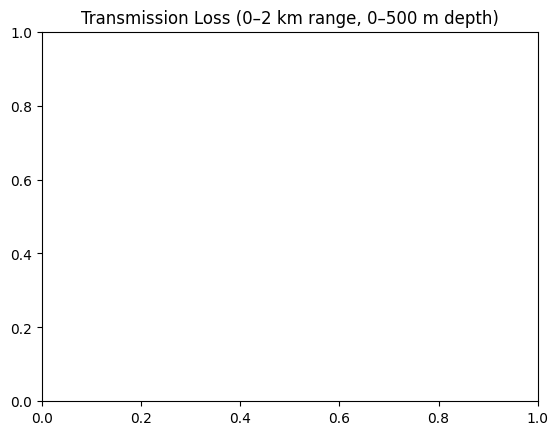

In [13]:
# -------------------------------------------------------
#  Stage 2A: Build ARLPY Environment from Extended SSP
# -------------------------------------------------------
import arlpy.uwapm as pm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- 1) Load your extended SSP file (from Stage 1 / previous step)
data_path = "/Users/abdullahabdelaizz/Myfiles/Underwater/bellhop_output/assets/extended_ssp_0_500m_v2.csv"
profile = pd.read_csv(data_path)   

# --- 2) Create ARLPY environment
env = pm.create_env2d(
    depth=500,                                    
    soundspeed=profile.values.tolist(),           # [[depth, c], ...]
    bottom_soundspeed=1600,                       # sand bottom (~1.6 km/s)
    bottom_density=1800,                          # kg/m³ (optional, default reasonable)
    bottom_absorption=0.8,                               # attenuation (dB/λ)
    rx_depth=np.linspace(5, 400, 10),             # receivers at 5–400 m (10 hydrophones)
    rx_range=np.linspace(0, 2000, 200),           # range 0–2 km (200 points)
    frequency=1500                                    # frequency (Hz)
)

# --- 3) Check and visualize environment
pm.check_env2d(env)
pm.print_env(env)
pm.plot_env(env)
pm.plot_ssp(env)

# --- 4) Compute transmission loss
tloss = pm.compute_transmission_loss(env, mode='incoherent')
pm.plot_transmission_loss(tloss, env=env, width=1000)
plt.title("Transmission Loss (0–2 km range, 0–500 m depth)")

# --- 5) Compute eigenrays and visualize
rays = pm.compute_eigenrays(env)
pm.plot_rays(rays, env=env, width=1000)

# --- 6) Compute arrivals and impulse response
arrivals = pm.compute_arrivals(env)
pm.plot_arrivals(arrivals)

ir = pm.arrivals_to_impulse_response(arrivals, fs=48000)
print(f"Impulse response length: {len(ir)} samples")

# --- 7) Save impulse response and metadata (optional)
np.save("./assets/ir_salish_env.npy", ir)

# optional: save transmission loss as CSV for later ML use
tloss_mag = np.abs(tloss)**2
np.savetxt("./assets/tloss_salish_env.csv", tloss_mag, delimiter=',')
